In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/listings_cleaned.csv")

print(df.shape)

(5864, 80)


In [3]:
features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "availability_365",
    "number_of_reviews"
]

target = "price_clean"

In [5]:
#remove missing value
df_ml = df[features + [target]].dropna()

print(df_ml.shape)

(5852, 7)


In [6]:
X = df_ml[features]

y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [9]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, pred_lr)
)

r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

Linear Regression
MAE : 104.09377540081076
RMSE: 378.71565429140526
R²  : 0.054629147785671406


In [11]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    pred_rf
)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 108.43238567727832
RMSE: 390.3490094307045
R²  : -0.004342537233660959


In [13]:
#lr vs rm
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,104.093775,378.715654,0.054629
1,Random Forest,108.432386,390.349009,-0.004343


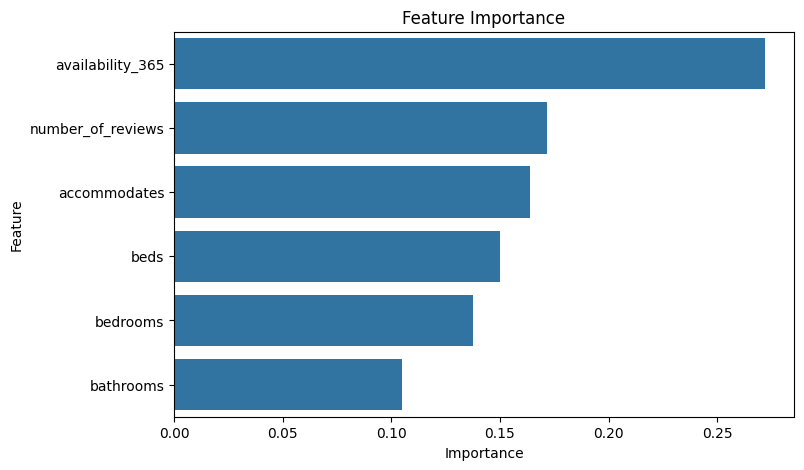

In [14]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.show()

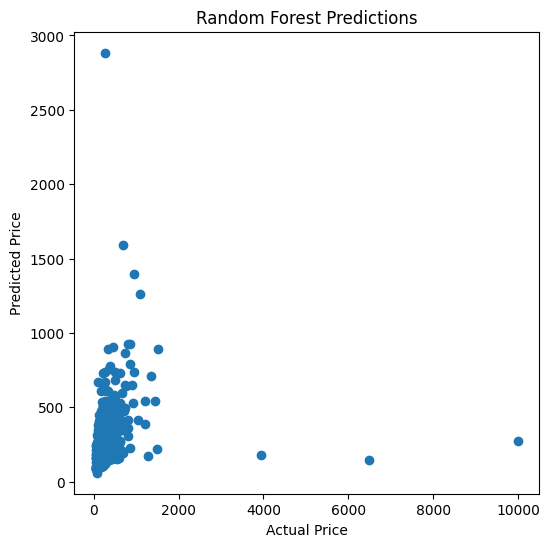

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred_rf
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Random Forest Predictions"
)

plt.show()